In [1]:
import mdtraj as md
import numpy as np
import os
import pandas as pd
from contact_map import ContactFrequency
from contact_map import ContactMap, ContactCount, ContactFrequency, ContactDifference, AtomMismatchedContactDifference
from numpy import *
import time

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from functools import reduce

In [2]:
n_sim = 10
asn_sim_frames_total = 4900000
con_sim_frames_total = 4800000
asn_framenum = asn_sim_frames_total * n_sim
con_framenum = con_sim_frames_total * n_sim
stride = 100 
asn_num = int(asn_framenum/stride)
con_num = int(con_framenum/stride)
asn_len = asn_sim_frames_total/stride
con_len = con_sim_frames_total/stride
row_num_contact_matrices = 23
k = 11 # number of clusters

In [3]:
s_time = time.time()
# Pathways to .csv files
csv_file_pa = '/data/kball/CTD/contact_map_clustering/pa_contact_matrices_noheader_every_' + str(stride) + '.csv'
csv_file_a = '/data/kball/CTD/contact_map_clustering/a_contact_matrices_noheader_every_' + str(stride) + '.csv'
csv_file_pc = '/data/kball/CTD/contact_map_clustering/pc_contact_matrices_noheader_every_' + str(stride) + '.csv'
csv_file_c = '/data/kball/CTD/contact_map_clustering/c_contact_matrices_noheader_every_' + str(stride) + '.csv'

# Read the .csv files and convert them into dataframes
df_list_pa = pd.read_csv(csv_file_pa, header=None) # 'header=None' converts header into first row of df
print("read ps5n7")
df_list_a = pd.read_csv(csv_file_a, header=None)
print("read s5n7")
df_list_pc = pd.read_csv(csv_file_pc, header=None)
print("read ps5s7")
df_list_c = pd.read_csv(csv_file_c, header=None)
print("read s5s7")

# Now split the big dataframes into 23x23 dataframes
df_contact_matrices_pa = np.array_split(df_list_pa, asn_num)
df_contact_matrices_a = np.array_split(df_list_a, asn_num)
df_contact_matrices_pc = np.array_split(df_list_pc, con_num)
df_contact_matrices_c = np.array_split(df_list_c, con_num)
e_time = time.time()
e_time - s_time

read ps5n7
read s5n7
read ps5s7
read s5s7


/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


128.35594749450684

In [4]:
def dataframes_list_to_arrays(list_of_dfs):
    list_of_arrays = []
    for df in list_of_dfs:
        numpy_array = df.to_numpy(na_value=0)
        list_of_arrays.append(numpy_array)
    return list_of_arrays

In [5]:
df_contact_matrices_pa

[     0    1    2    3    4    5    6    7    8    9   ...   13   14   15   16  \
 0   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  1.0  1.0   
 1   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  1.0  1.0  1.0   
 2   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  1.0  0.0   
 3   0.0  0.0  0.0  0.0  0.0  0.0  0.0  1.0  0.0  0.0  ...  0.0  1.0  0.0  0.0   
 4   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 5   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 6   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0  0.0   
 7   0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  0.0  1.0  0.0  0.0   
 8   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  1.0  1.0  0.0  1.0   
 9   0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  1.0  1.0  0.0  0.0   
 10  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  ...  1.0  1.0  0.0  0.0   
 11  0.0  0.0  1

In [9]:
len(array_contact_matrices_pa)

NameError: name 'array_contact_matrices_pa' is not defined

In [10]:
len(array_contact_matrices_a)

NameError: name 'array_contact_matrices_a' is not defined

In [11]:
len(array_contact_matrices_pc)

NameError: name 'array_contact_matrices_pc' is not defined

In [12]:
len(array_contact_matrices_c)

NameError: name 'array_contact_matrices_c' is not defined

In [13]:
# read in frame weights
pa_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/asparagine/ps5n7/reweighting/weights_by_frame_MC-order10.dat', header=None)
a_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/asparagine/s5n7/reweighting/weights_by_frame_MC-order10.dat', header=None)
pc_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/consensus/ps5s7/reweighting/weights_by_frame_MC-order10.dat', header=None)
c_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/consensus/s5s7/reweighting/weights_by_frame_MC-order10.dat', header=None)

In [14]:
# select out stride
pa_weights_stride = pa_weights_combined_raw.iloc[::stride]
a_weights_stride = a_weights_combined_raw.iloc[::stride]
pc_weights_stride = pc_weights_combined_raw.iloc[::stride]
c_weights_stride = c_weights_combined_raw.iloc[::stride]

In [15]:
# normalize the weights
pa_weights_combined = pa_weights_stride/pa_weights_stride.sum()
a_weights_combined = a_weights_stride/a_weights_stride.sum()
pc_weights_combined = pc_weights_stride/pc_weights_stride.sum()
c_weights_combined = c_weights_stride/c_weights_stride.sum()

In [16]:
pa_weights_array = pa_weights_combined.to_numpy()
a_weights_array = a_weights_combined.to_numpy()
pc_weights_array = pc_weights_combined.to_numpy()
c_weights_array = c_weights_combined.to_numpy()

In [17]:
pa_weighted_contact_matrices = df_contact_matrices_pa.copy()
for frame, matrix in enumerate(df_contact_matrices_pa):
    pa_weighted_contact_matrices[frame] = matrix*pa_weights_array[frame,0]
pa_weighted_contact_matrices[0]

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000003,0.000003,0.000003,0.0,0.000000,0.0,0.0,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000003,0.000003,0.000003,0.000003,0.0,0.000000,0.0,0.0,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000003,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000003,0.000000,0.000000,...,0.000000,0.000003,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
5,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
7,0.000000,0.000000,0.000000,0.000003,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000003,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000003,0.000003,0.000000,0.000003,0.000000,0.0,0.000000,0.0,0.0,0.000000
9,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000003,0.000003,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000


In [18]:
a_weighted_contact_matrices = df_contact_matrices_a.copy()
for frame, matrix in enumerate(df_contact_matrices_a):
    a_weighted_contact_matrices[frame] = matrix*a_weights_array[frame,0]

pc_weighted_contact_matrices = df_contact_matrices_pc.copy()
for frame, matrix in enumerate(df_contact_matrices_pc):
    pc_weighted_contact_matrices[frame] = matrix*pc_weights_array[frame,0]

c_weighted_contact_matrices = df_contact_matrices_c.copy()
for frame, matrix in enumerate(df_contact_matrices_c):
    c_weighted_contact_matrices[frame] = matrix*c_weights_array[frame,0]

In [19]:
len(pa_weighted_contact_matrices)

490000

In [20]:
s_time = time.time()
with open('pS5N7_Ser5_Ser12_contacts_every_' + str(stride) +  '.txt', 'w') as f:
    pa_avg_contact_map = pa_weighted_contact_matrices[0]
    print(f"0\t{pa_weighted_contact_matrices[0][5][12]}", file = f)
    for frame in range (1, len(pa_weighted_contact_matrices)):
        reset_matrix = pa_weighted_contact_matrices[frame].reset_index(drop=True)
        pa_avg_contact_map = pa_avg_contact_map.add(reset_matrix)
        print(f"{frame}\t{reset_matrix[5][12]}", file = f)

e_time = time.time()
e_time - s_time

54.989415407180786

In [21]:
%pwd

'/data/mcohen3/CTD'

In [22]:
pa_avg_contact_map.max().max()

0.3861062476772931

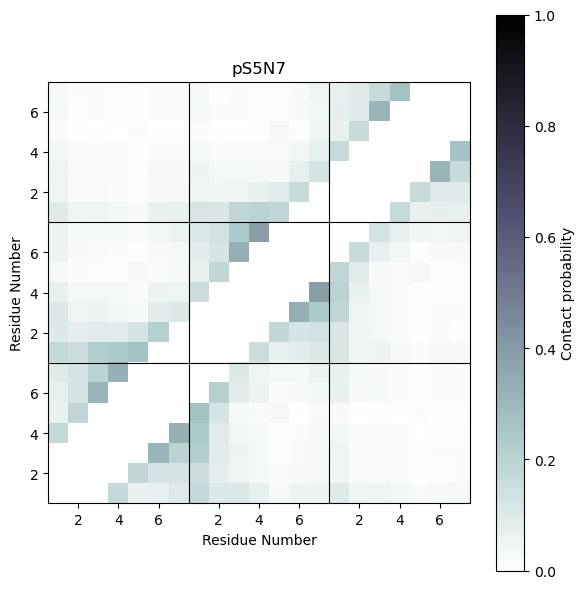

In [23]:
plt.figure(figsize=(6,6))
plt.imshow(pa_avg_contact_map, origin='lower', cmap='bone_r', vmin=0, vmax=1)
plt.title(f"pS5N7")
plt.xlabel("Residue Number")
plt.ylabel("Residue Number")
plt.colorbar(label='Contact probability') #set to 1


plt.xticks([2, 4, 6, 9, 11, 13, 16, 18, 20], ['2', '4', '6', '2', '4', '6', '2', '4', '6']) 
plt.yticks([2, 4, 6, 9, 11, 13, 16, 18, 20], ['2', '4', '6', '2', '4', '6', '2', '4', '6']) 
plt.xlim([0.5, 21.5])
plt.ylim([0.5, 21.5])

plt.axline((0, 7.5), (1, 7.5), color='black', linestyle='-', linewidth=0.8)        #horizontal lines
plt.axline((0, 14.5), (1, 14.5), color='black', linestyle='-', linewidth=0.8)

plt.axline((7.5, 0), (7.5, 1), color='black', linestyle='-', linewidth=0.8)        #vertical lines
plt.axline((14.5, 0), (14.5, 1), color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
#plt.savefig('/data/kball/CTD/contact_map_clustering/figures/pS5N7_contact_map_every_' + str(stride) + '.pdf', dpi = 1000)

In [24]:
s_time = time.time()
with open('S5N7_Ser5_Ser12_contacts_every_' + str(stride) +  '.txt', 'w') as f:
    a_avg_contact_map = a_weighted_contact_matrices[0]
    print(f"0\t{a_weighted_contact_matrices[0][5][12]}", file = f)
    for frame in range (1, len(a_weighted_contact_matrices)):
        reset_matrix = a_weighted_contact_matrices[frame].reset_index(drop=True)
        a_avg_contact_map = a_avg_contact_map.add(reset_matrix)
        print(f"{frame}\t{reset_matrix[5][12]}", file = f)

e_time = time.time()
e_time - s_time

55.102659463882446

In [25]:
a_avg_contact_map.max().max()

0.3111689982057707

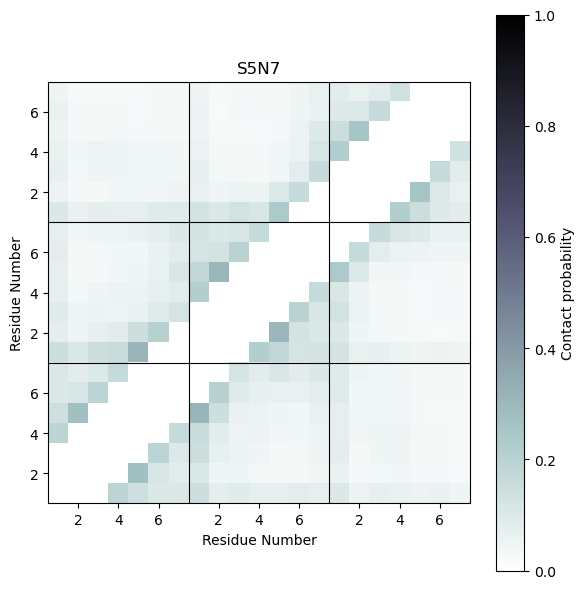

In [26]:
plt.figure(figsize=(6,6))
plt.imshow(a_avg_contact_map, origin='lower', cmap='bone_r', vmin=0, vmax=1)
plt.title(f"S5N7")
plt.xlabel("Residue Number")
plt.ylabel("Residue Number")
plt.colorbar(label='Contact probability') #set to 1


plt.xticks([2, 4, 6, 9, 11, 13, 16, 18, 20], ['2', '4', '6', '2', '4', '6', '2', '4', '6']) 
plt.yticks([2, 4, 6, 9, 11, 13, 16, 18, 20], ['2', '4', '6', '2', '4', '6', '2', '4', '6']) 
plt.xlim([0.5, 21.5])
plt.ylim([0.5, 21.5])

plt.axline((0, 7.5), (1, 7.5), color='black', linestyle='-', linewidth=0.8)        #horizontal lines
plt.axline((0, 14.5), (1, 14.5), color='black', linestyle='-', linewidth=0.8)

plt.axline((7.5, 0), (7.5, 1), color='black', linestyle='-', linewidth=0.8)        #vertical lines
plt.axline((14.5, 0), (14.5, 1), color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
#plt.savefig('/data/kball/CTD/contact_map_clustering/figures/S5N7_contact_map_every_' + str(stride) + '.pdf', dpi = 1000)

In [27]:
Asn_diff_contact_map = pa_avg_contact_map - a_avg_contact_map
Asn_diff_contact_map

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,0.000000,0.000000,0.000000,-0.009599,-0.010008,-0.033544,-0.014830,-0.010715,-0.003789,0.003162,...,-0.010366,-0.004233,-0.004759,-0.002511,-0.009662,-0.007646,-0.014705,-0.009796,-0.010543,-0.004543
1,0.000000,0.000000,0.000000,0.000000,-0.021434,-0.080391,-0.031867,-0.010687,0.022195,0.020421,...,-0.025462,-0.016421,-0.010748,-0.010042,-0.018360,-0.021212,-0.034781,-0.029643,-0.019459,-0.009021
2,0.000000,0.000000,0.000000,0.000000,0.000000,-0.094884,0.005769,0.037162,0.044892,0.025909,...,-0.012304,-0.015284,-0.017725,-0.013001,-0.017151,-0.024169,-0.022496,-0.018316,-0.013816,-0.005523
3,-0.009599,0.000000,0.000000,0.000000,0.000000,0.000000,0.117206,0.098528,0.072455,0.018627,...,-0.017517,-0.018868,-0.025182,-0.016890,-0.023792,-0.032196,-0.029090,-0.021476,-0.013253,-0.005431
4,-0.010008,-0.021434,0.000000,0.000000,0.000000,0.000000,0.000000,0.160235,0.075786,0.003692,...,-0.026446,-0.025688,-0.036162,-0.026119,-0.027697,-0.036890,-0.034453,-0.023687,-0.016212,-0.005623
5,-0.033544,-0.080391,-0.094884,0.000000,0.000000,0.000000,0.000000,0.000000,-0.042405,-0.023684,...,-0.034027,-0.044680,-0.050496,-0.033126,-0.033216,-0.036759,-0.014548,-0.020876,-0.015996,-0.006637
6,-0.014830,-0.031867,0.005769,0.117206,0.000000,0.000000,0.000000,0.000000,0.000000,0.004568,...,-0.035962,-0.041291,-0.031273,-0.020830,-0.017167,-0.025026,-0.026237,-0.018625,-0.017207,-0.005813
7,-0.010715,-0.010687,0.037162,0.098528,0.160235,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.048866,-0.049149,-0.027918,-0.019125,-0.018557,-0.029664,-0.028966,-0.018983,-0.018926,-0.007245
8,-0.003789,0.022195,0.044892,0.072455,0.075786,-0.042405,0.000000,0.000000,0.000000,0.000000,...,-0.044496,-0.024630,-0.011118,-0.014515,-0.016174,-0.028565,-0.034894,-0.023261,-0.023548,-0.008968
9,0.003162,0.020421,0.025909,0.018627,0.003692,-0.023684,0.004568,0.000000,0.000000,0.000000,...,-0.008495,0.029310,0.008256,-0.002204,-0.008884,-0.019769,-0.018352,-0.010698,-0.016428,-0.006877


In [93]:
pa_avg_contact_map[11][14]

0.3861062476772931

In [95]:
a_avg_contact_map[11][14]

0.1658435242910454

In [96]:
pc_avg_contact_map[11][14]

0.2926146537071259

In [97]:
c_avg_contact_map[11][14]

0.15943272052916505

In [98]:
pa_avg_contact_map[9][12]

0.17189954237466437

In [99]:
a_avg_contact_map[9][12]

0.30084300177632234

In [100]:
pc_avg_contact_map[9][12]

0.1123901553728144

In [101]:
c_avg_contact_map[9][12]

0.2891324162548286

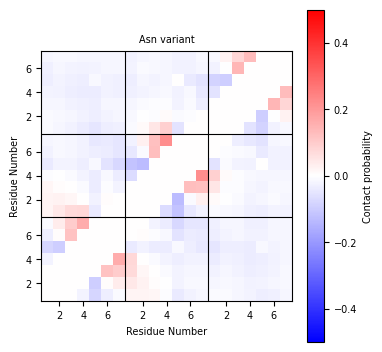

In [30]:
plt.figure(figsize=(6,6))
plt.imshow(Asn_diff_contact_map, origin='lower', cmap='bwr', vmin=-0.5, vmax=0.5)
plt.title(f"Asn variant", fontsize=7)
plt.xlabel("Residue Number", fontsize=7)
plt.ylabel("Residue Number", fontsize=7)
cbar = plt.colorbar(label='Contact probability') #set to 1

cbar.ax.tick_params(labelsize=7)
cbar.set_label('Contact probability', size=7)

plt.xticks([2, 4, 6, 9, 11, 13, 16, 18, 20], ['2', '4', '6', '2', '4', '6', '2', '4', '6'], fontsize=7) 
plt.yticks([2, 4, 6, 9, 11, 13, 16, 18, 20], ['2', '4', '6', '2', '4', '6', '2', '4', '6'], fontsize=7) 
plt.xlim([0.5, 21.5])
plt.ylim([0.5, 21.5])

plt.axline((0, 7.5), (1, 7.5), color='black', linestyle='-', linewidth=0.8)        #horizontal lines
plt.axline((0, 14.5), (1, 14.5), color='black', linestyle='-', linewidth=0.8)

plt.axline((7.5, 0), (7.5, 1), color='black', linestyle='-', linewidth=0.8)        #vertical lines
plt.axline((14.5, 0), (14.5, 1), color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
#plt.savefig('/data/kball/CTD/contact_map_clustering/figures/Asn_diff_contact_map_every_' + str(stride) + '.pdf', dpi = 1000)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
#print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.5

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
#print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('cluster_figs/Asn_diff_contact_map_every_' + str(stride) + '.png', dpi = 1000, bbox_inches='tight')
plt.show()

In [41]:
s_time = time.time()
with open('pS5S7_Ser5_Ser12_contacts_every_' + str(stride) +  '.txt', 'w') as f:
    pc_avg_contact_map = pc_weighted_contact_matrices[0]
    print(f"0\t{pc_weighted_contact_matrices[0][5][12]}", file = f)
    for frame in range (1, len(pc_weighted_contact_matrices)):
        reset_matrix = pc_weighted_contact_matrices[frame].reset_index(drop=True)
        pc_avg_contact_map = pc_avg_contact_map.add(reset_matrix)
        print(f"{frame}\t{reset_matrix[5][12]}", file = f)

e_time = time.time()
e_time - s_time

51.90184473991394

In [42]:
pc_avg_contact_map.max().max()

0.37409129225201826

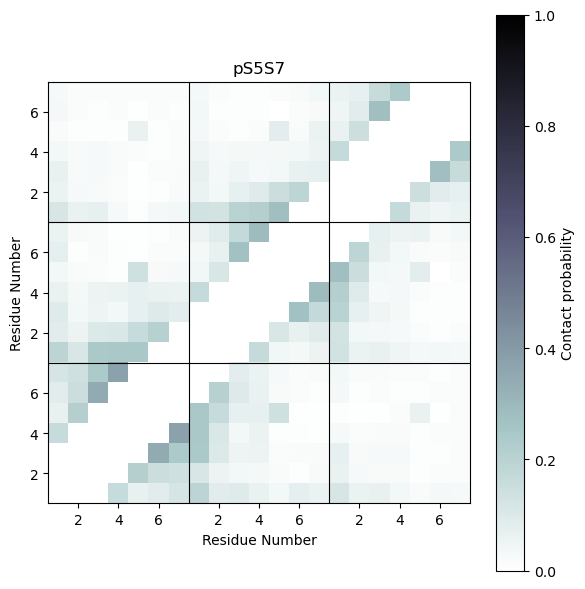

In [43]:
plt.figure(figsize=(6,6))
plt.imshow(pc_avg_contact_map, origin='lower', cmap='bone_r', vmin=0, vmax=1)
plt.title(f"pS5S7")
plt.xlabel("Residue Number")
plt.ylabel("Residue Number")
plt.colorbar(label='Contact probability') #set to 1


plt.xticks([2, 4, 6, 9, 11, 13, 16, 18, 20], ['2', '4', '6', '2', '4', '6', '2', '4', '6']) 
plt.yticks([2, 4, 6, 9, 11, 13, 16, 18, 20], ['2', '4', '6', '2', '4', '6', '2', '4', '6']) 
plt.xlim([0.5, 21.5])
plt.ylim([0.5, 21.5])

plt.axline((0, 7.5), (1, 7.5), color='black', linestyle='-', linewidth=0.8)        #horizontal lines
plt.axline((0, 14.5), (1, 14.5), color='black', linestyle='-', linewidth=0.8)

plt.axline((7.5, 0), (7.5, 1), color='black', linestyle='-', linewidth=0.8)        #vertical lines
plt.axline((14.5, 0), (14.5, 1), color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
#plt.savefig('/data/kball/CTD/contact_map_clustering/figures/pS5S7_contact_map_every_' + str(stride) + '.pdf', dpi = 1000)

In [102]:
pc_avg_contact_map[5][12]

0.1389135178798287

In [103]:
pc_avg_contact_map[5][19]

0.061694427157067834

In [104]:
pc_avg_contact_map[12][19]

0.08121601409185229

In [44]:
s_time = time.time()
with open('S5S7_Ser5_Ser12_contacts_every_' + str(stride) +  '.txt', 'w') as f:
    c_avg_contact_map = c_weighted_contact_matrices[0]
    print(f"0\t{c_weighted_contact_matrices[0][5][12]}", file = f)
    for frame in range (1, len(c_weighted_contact_matrices)):
        reset_matrix = c_weighted_contact_matrices[frame].reset_index(drop=True)
        c_avg_contact_map = c_avg_contact_map.add(reset_matrix)
        print(f"{frame}\t{reset_matrix[5][12]}", file = f)

e_time = time.time()
e_time - s_time

52.191306829452515

In [45]:
c_avg_contact_map.max().max()

0.33474769598418264

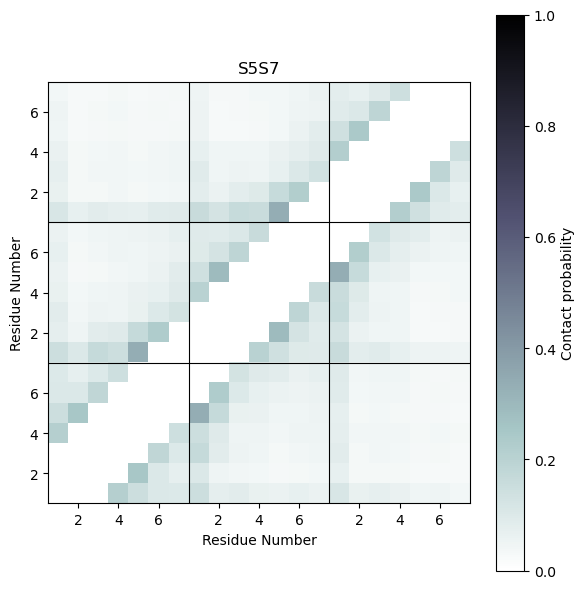

In [46]:
plt.figure(figsize=(6,6))
plt.imshow(c_avg_contact_map, origin='lower', cmap='bone_r', vmin=0, vmax=1)
plt.title(f"S5S7")
plt.xlabel("Residue Number")
plt.ylabel("Residue Number")
plt.colorbar(label='Contact probability') #set to 1


plt.xticks([2, 4, 6, 9, 11, 13, 16, 18, 20], ['2', '4', '6', '2', '4', '6', '2', '4', '6']) 
plt.yticks([2, 4, 6, 9, 11, 13, 16, 18, 20], ['2', '4', '6', '2', '4', '6', '2', '4', '6']) 
plt.xlim([0.5, 21.5])
plt.ylim([0.5, 21.5])

plt.axline((0, 7.5), (1, 7.5), color='black', linestyle='-', linewidth=0.8)        #horizontal lines
plt.axline((0, 14.5), (1, 14.5), color='black', linestyle='-', linewidth=0.8)

plt.axline((7.5, 0), (7.5, 1), color='black', linestyle='-', linewidth=0.8)        #vertical lines
plt.axline((14.5, 0), (14.5, 1), color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
#plt.savefig('/data/kball/CTD/contact_map_clustering/figures/S5S7_contact_map_every_' + str(stride) + '.pdf', dpi = 1000)

In [47]:
Con_diff_contact_map = pc_avg_contact_map - c_avg_contact_map

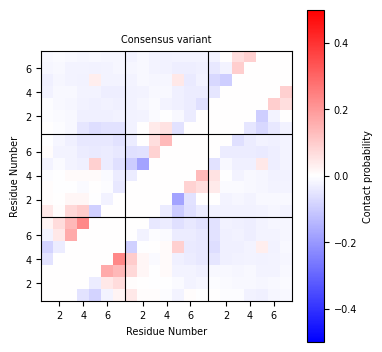

In [49]:
plt.figure(figsize=(6,6))
plt.imshow(Con_diff_contact_map, origin='lower', cmap='bwr', vmin=-0.5, vmax=0.5)
plt.title(f"Consensus variant", fontsize=7)
plt.xlabel("Residue Number", fontsize=7)
plt.ylabel("Residue Number", fontsize=7)
cbar = plt.colorbar(label='Contact probability') #set to 1

cbar.ax.tick_params(labelsize=7)
cbar.set_label('Contact probability', size=7)

plt.xticks([2, 4, 6, 9, 11, 13, 16, 18, 20], ['2', '4', '6', '2', '4', '6', '2', '4', '6'], fontsize=7) 
plt.yticks([2, 4, 6, 9, 11, 13, 16, 18, 20], ['2', '4', '6', '2', '4', '6', '2', '4', '6'], fontsize=7) 
plt.xlim([0.5, 21.5])
plt.ylim([0.5, 21.5])

plt.axline((0, 7.5), (1, 7.5), color='black', linestyle='-', linewidth=0.8)        #horizontal lines
plt.axline((0, 14.5), (1, 14.5), color='black', linestyle='-', linewidth=0.8)

plt.axline((7.5, 0), (7.5, 1), color='black', linestyle='-', linewidth=0.8)        #vertical lines
plt.axline((14.5, 0), (14.5, 1), color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
#plt.savefig('/data/kball/CTD/contact_map_clustering/figures/Con_diff_contact_map_every_' + str(stride) + '.pdf', dpi = 1000)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
#print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.5

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
#print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('cluster_figs/Con_diff_contact_map_every_' + str(stride) + '.png', dpi = 1000, bbox_inches='tight')
plt.show()

In [50]:
Phos_diff_contact_map = pa_avg_contact_map - pc_avg_contact_map
Unphos_diff_contact_map = a_avg_contact_map - c_avg_contact_map

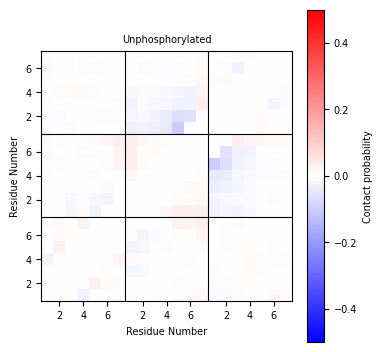

In [52]:
plt.figure(figsize=(6,6))
plt.imshow(Unphos_diff_contact_map, origin='lower', cmap='bwr', vmin=-0.5, vmax=0.5)
plt.title(f"Unphosphorylated", fontsize=7)
plt.xlabel("Residue Number", fontsize=7)
plt.ylabel("Residue Number", fontsize=7)
cbar = plt.colorbar(label='Contact probability') #set to 1

cbar.ax.tick_params(labelsize=7)
cbar.set_label('Contact probability', size=7)

plt.xticks([2, 4, 6, 9, 11, 13, 16, 18, 20], ['2', '4', '6', '2', '4', '6', '2', '4', '6'], fontsize=7) 
plt.yticks([2, 4, 6, 9, 11, 13, 16, 18, 20], ['2', '4', '6', '2', '4', '6', '2', '4', '6'], fontsize=7) 
plt.xlim([0.5, 21.5])
plt.ylim([0.5, 21.5])

plt.axline((0, 7.5), (1, 7.5), color='black', linestyle='-', linewidth=0.8)        #horizontal lines
plt.axline((0, 14.5), (1, 14.5), color='black', linestyle='-', linewidth=0.8)

plt.axline((7.5, 0), (7.5, 1), color='black', linestyle='-', linewidth=0.8)        #vertical lines
plt.axline((14.5, 0), (14.5, 1), color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
#plt.savefig('/data/kball/CTD/contact_map_clustering/figures/Unphos_diff_contact_map_every_' + str(stride) + '.pdf', dpi = 1000)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
#print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.5

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
#print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('cluster_figs/Unphos_diff_contact_map_every_' + str(stride) + '.png', dpi = 1000, bbox_inches='tight')
plt.show()

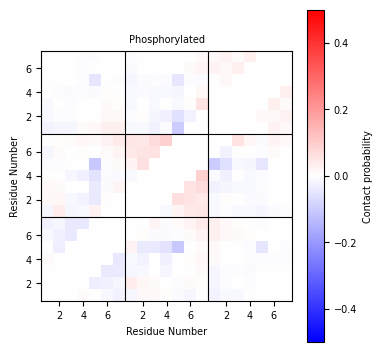

In [53]:
plt.figure(figsize=(6,6))
plt.imshow(Phos_diff_contact_map, origin='lower', cmap='bwr', vmin=-0.5, vmax=0.5)
plt.title(f"Phosphorylated", fontsize=7)
plt.xlabel("Residue Number", fontsize=7)
plt.ylabel("Residue Number", fontsize=7)
cbar = plt.colorbar(label='Contact probability') #set to 1

cbar.ax.tick_params(labelsize=7)
cbar.set_label('Contact probability', size=7)

plt.xticks([2, 4, 6, 9, 11, 13, 16, 18, 20], ['2', '4', '6', '2', '4', '6', '2', '4', '6'], fontsize=7) 
plt.yticks([2, 4, 6, 9, 11, 13, 16, 18, 20], ['2', '4', '6', '2', '4', '6', '2', '4', '6'], fontsize=7) 
plt.xlim([0.5, 21.5])
plt.ylim([0.5, 21.5])

plt.axline((0, 7.5), (1, 7.5), color='black', linestyle='-', linewidth=0.8)        #horizontal lines
plt.axline((0, 14.5), (1, 14.5), color='black', linestyle='-', linewidth=0.8)

plt.axline((7.5, 0), (7.5, 1), color='black', linestyle='-', linewidth=0.8)        #vertical lines
plt.axline((14.5, 0), (14.5, 1), color='black', linestyle='-', linewidth=0.8)

plt.tight_layout()
#plt.savefig('/data/kball/CTD/contact_map_clustering/figures/Phos_diff_contact_map_every_' + str(stride) + '.pdf', dpi = 1000)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
#print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.5

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
#print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('cluster_figs/Phos_diff_contact_map_every_' + str(stride) + '.png', dpi = 1000, bbox_inches='tight')
plt.show()